In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/Titanic-Dataset.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

/tmp/ipykernel_3093/1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [7]:
df['Age'].isnull().sum()

np.int64(0)

In [8]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_3093/3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [9]:
df['Embarked'].isnull().sum()

np.int64(0)

In [10]:
df.drop('Cabin', axis=1, inplace=True)

In [11]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# **Histogram of Age**
This Histogram tells us about the Age of Passengers and the numbers of Passenger in a age bracket like most are in 20 to 30 years of age.


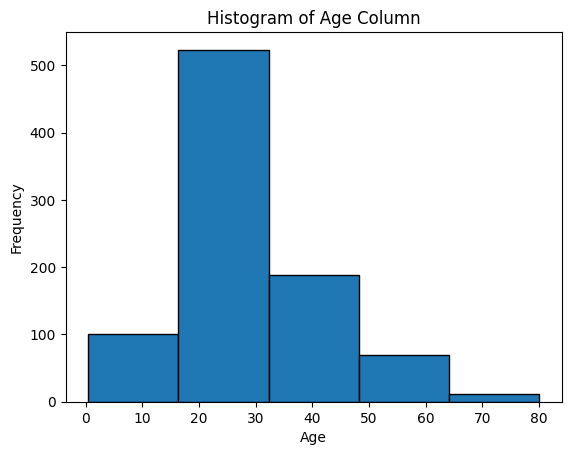

In [12]:
#Creating Histogram of Age Column Task 1
df['Age'].hist(bins=5, edgecolor='black', grid=False)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Age Column')
plt.show()

# Average Fare by Passenger Class
This graph tell us about the average fare that was charged per class

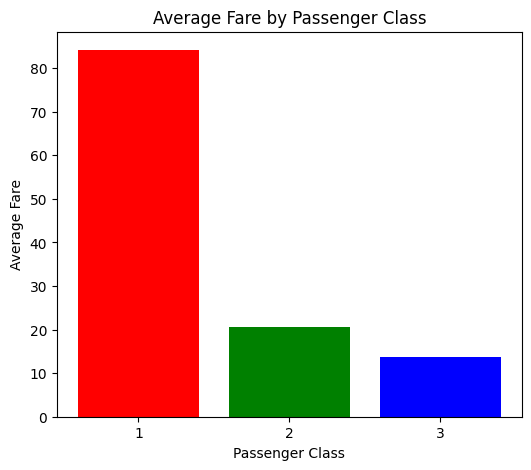

In [38]:
avg_fare = df.groupby("Pclass")["Fare"].mean()

plt.figure(figsize=(6,5))

plt.bar(avg_fare.index.astype(str),
        avg_fare.values,
        color=["red","green","blue"])

plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")

plt.show()

# Average age by Pssenger Class
This graph shows that what is the average age of passengers in each class

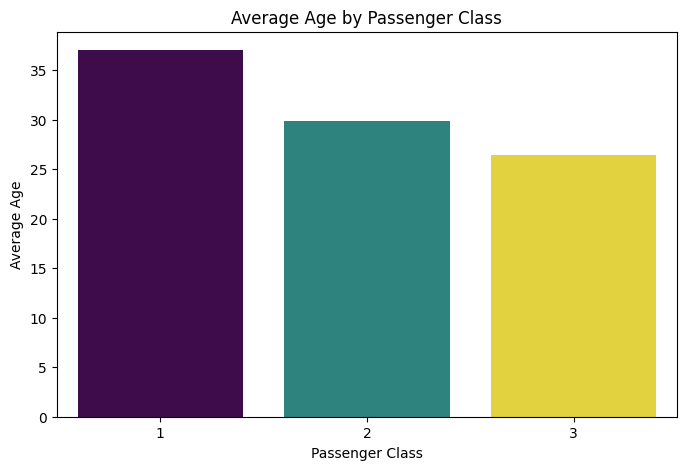

In [13]:
# Calculate average age grouped by Pclass
avg_age_by_class = df.groupby('Pclass')['Age'].mean().reset_index()

# Plotting the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Age', data=avg_age_by_class, palette='viridis', hue='Pclass', legend=False)

plt.xlabel('Passenger Class')
plt.ylabel('Average Age')
plt.title('Average Age by Passenger Class')
plt.show()

#Number of Survivors
In this number of survivers are calculated. Count the survivers 1=Yes and 0=No.

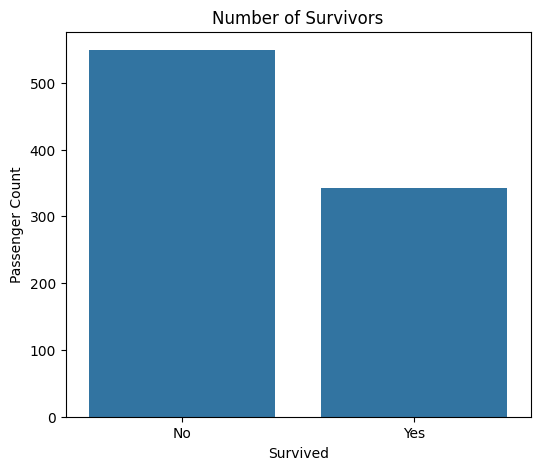

In [39]:
plt.figure(figsize=(6,5))

sns.countplot(x="Survived", data=df)

plt.title("Number of Survivors")
plt.xlabel("Survived")
plt.ylabel("Passenger Count")

plt.xticks([0,1],["No","Yes"])

plt.show()

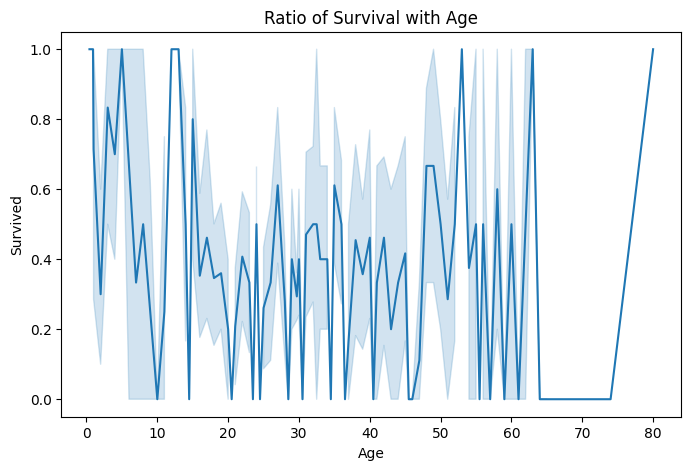

In [15]:
#graph which shows the ratio of survival
plt.figure(figsize=(8, 5))
sns.lineplot(x=df['Age'],y=df['Survived'])
plt.xlabel('Age')
plt.ylabel('Survived')
plt.title('Ratio of Survival with Age')
plt.show()


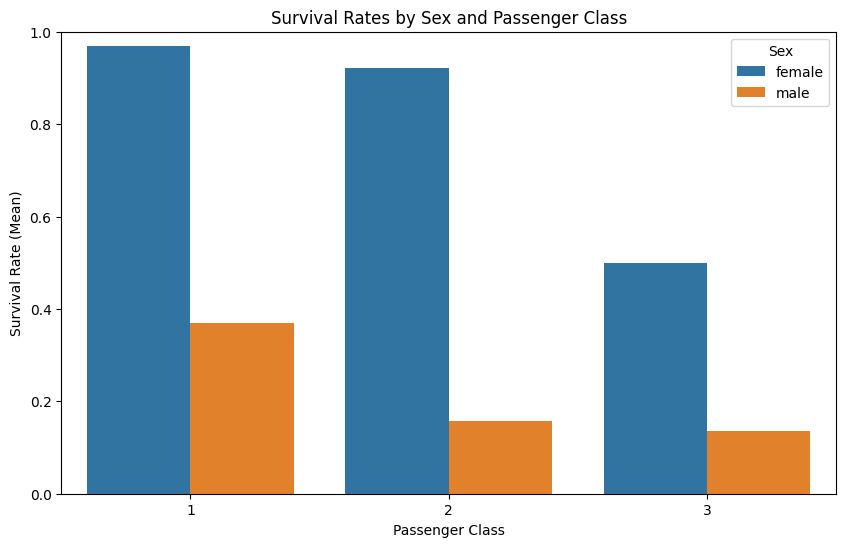

In [16]:
# Calculate survival rates by Sex and Pclass
survival_rates_grouped = df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()

# Plotting the grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=survival_rates_grouped)

plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (Mean)')
plt.title('Survival Rates by Sex and Passenger Class')
plt.ylim(0, 1)
plt.legend(title='Sex')
plt.show()

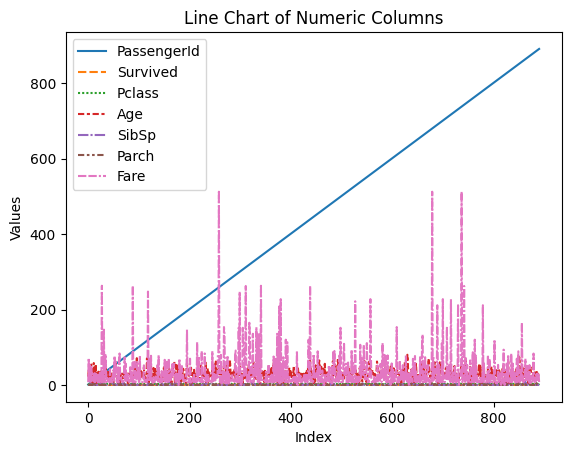

In [17]:
#checking the numeric tables by plotting them on line chart
sns.lineplot(data=df)
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Line Chart of Numeric Columns')
plt.show()

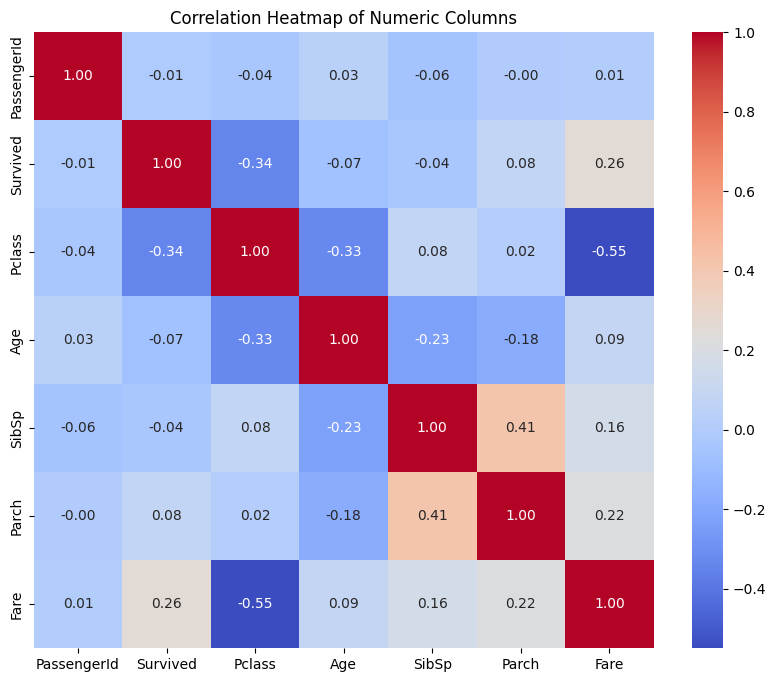

In [18]:
# Calculate correlation matrix for numeric columns
#finding the numeric columns
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Creating the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Columns')
plt.show()

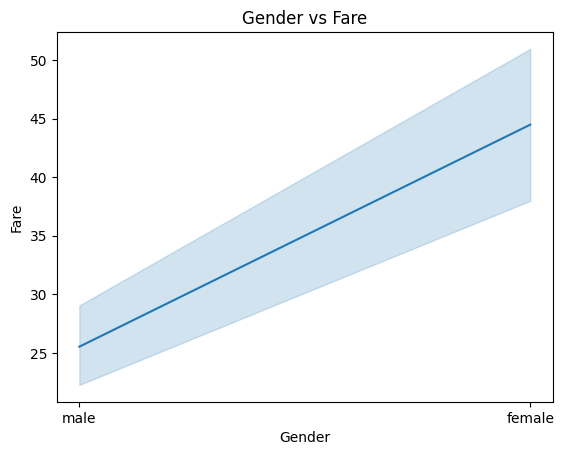

In [19]:
#line graph showing gender and fare prices
sns.lineplot(x=df['Sex'],y=df['Fare'])
plt.xlabel('Gender')
plt.ylabel('Fare')
plt.title('Gender vs Fare')
plt.show()

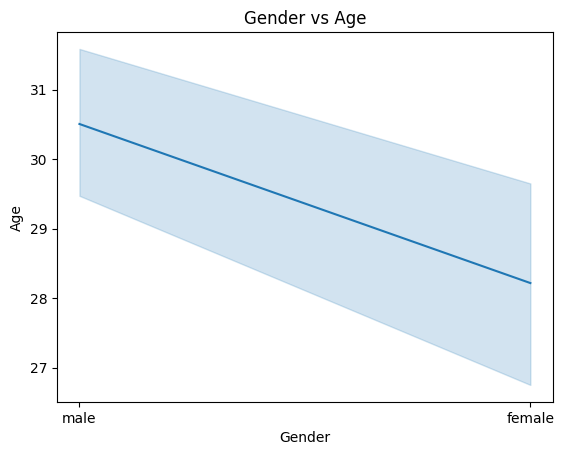

In [20]:
sns.lineplot(x=df['Sex'],y=df['Age'])
plt.xlabel('Gender')
plt.ylabel('Age')
plt.title('Gender vs Age')
plt.show()

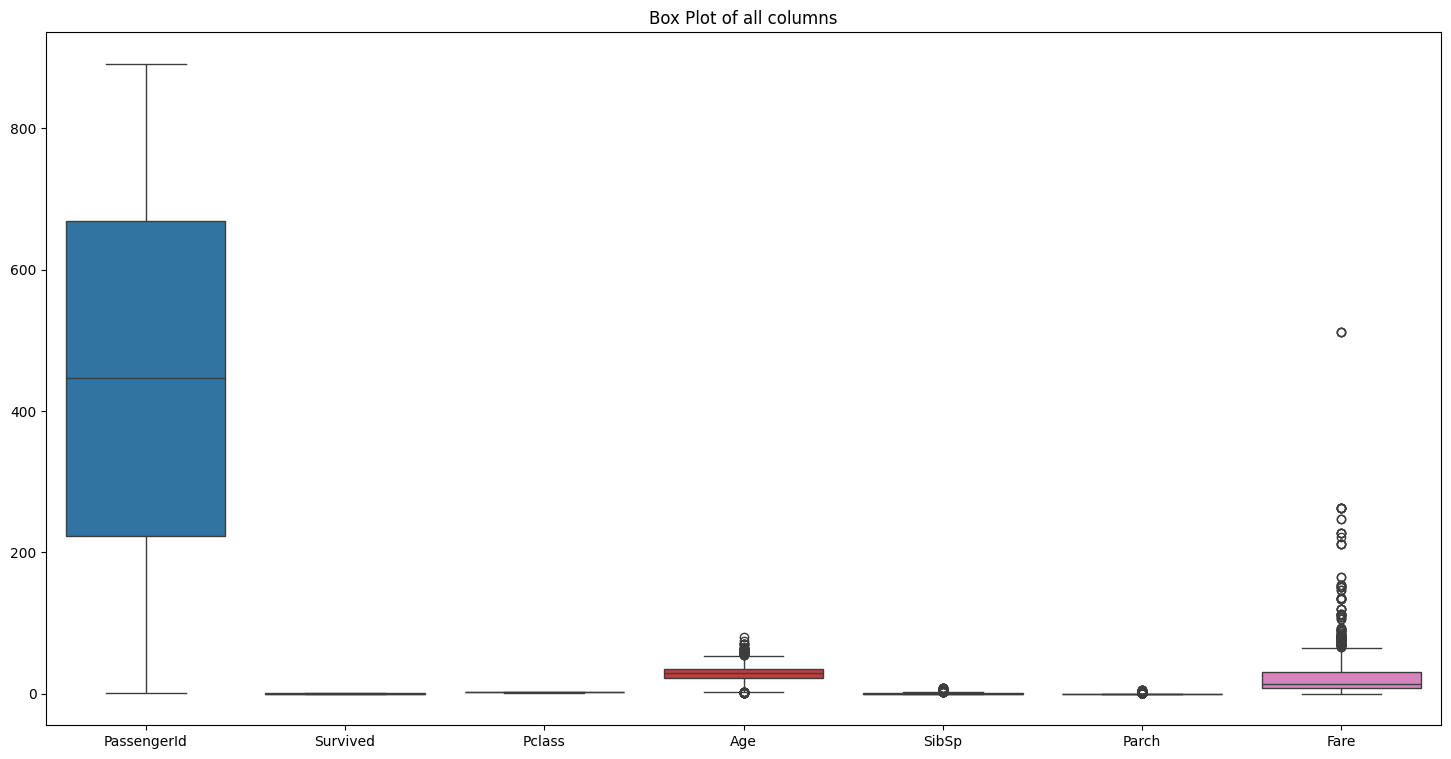

In [27]:
#box plot combined of all numeric tables
plt.figure(figsize=(18, 9))
sns.boxplot(data=df)
plt.title('Box Plot of all columns')
plt.show()

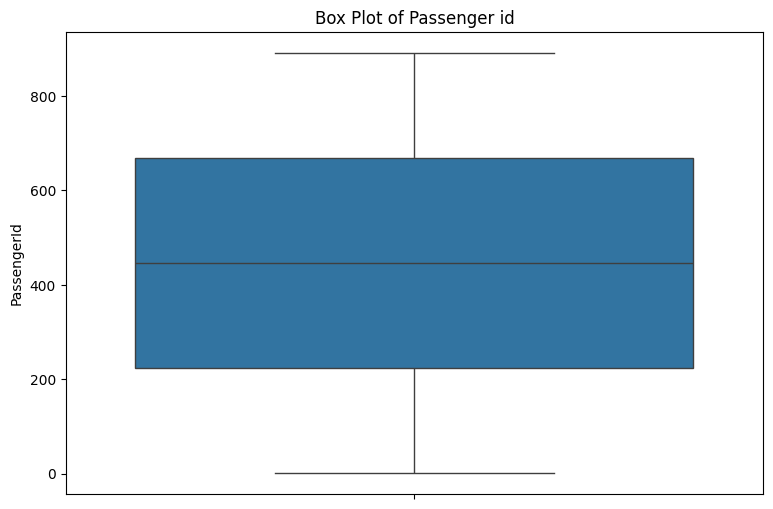

In [33]:
#box plot of passenger id
plt.figure(figsize=(9, 6))
sns.boxplot(data=df['PassengerId'])
plt.title('Box Plot of Passenger id')
plt.show()

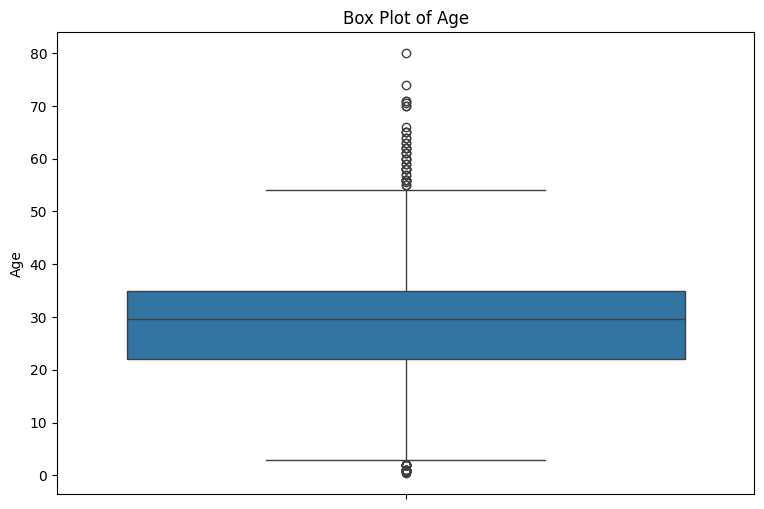

In [32]:
#box plot Age
plt.figure(figsize=(9, 6))
sns.boxplot(data=df['Age'])
plt.title('Box Plot of Age')
plt.show()

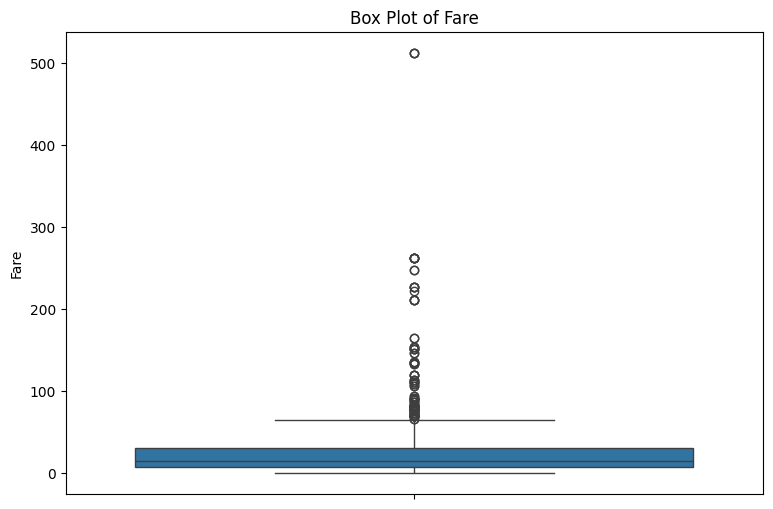

In [31]:
#box plot of FARE
plt.figure(figsize=(9, 6))
sns.boxplot(data=df['Fare'])
plt.title('Box Plot of Fare')
plt.show()

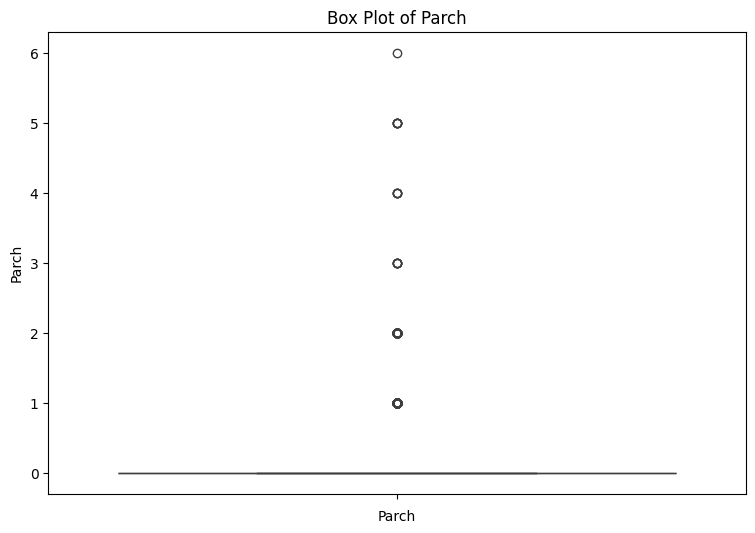

In [34]:
#box plot of Parch
plt.figure(figsize=(9, 6))
sns.boxplot(data=df['Parch'])
plt.title('Box Plot of Parch')
plt.xlabel('Parch')
plt.show()

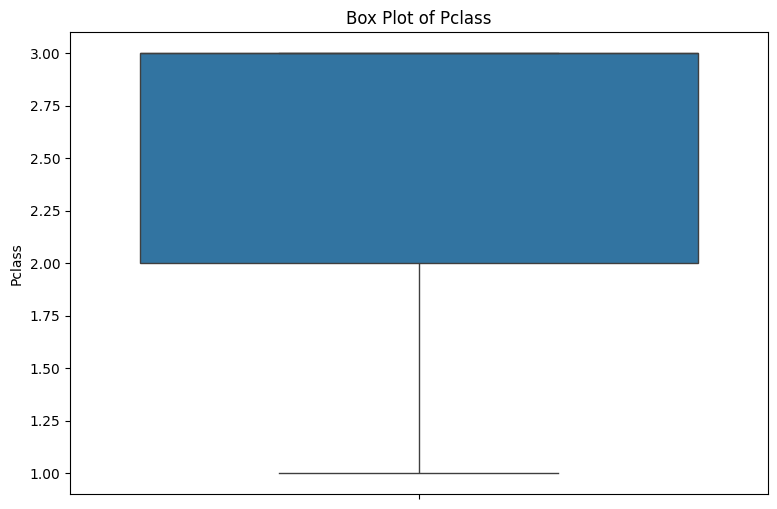

In [35]:
#box plot Pclass
plt.figure(figsize=(9, 6))
sns.boxplot(data=df['Pclass'])
plt.title('Box Plot of Pclass')
plt.show()

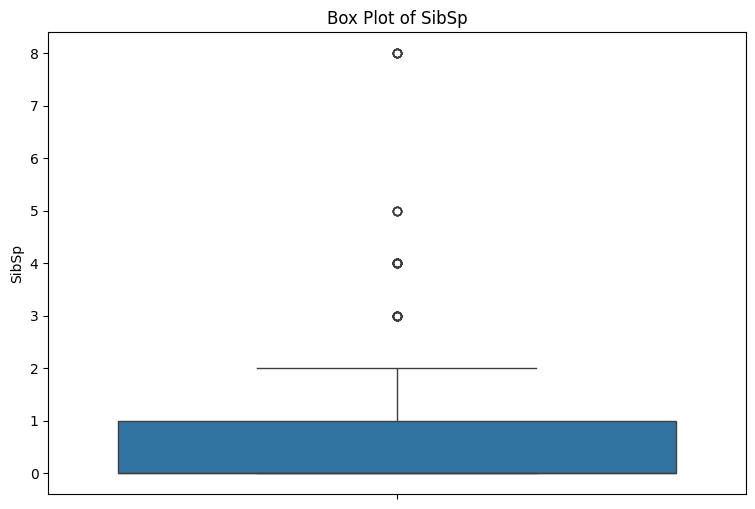

In [37]:
#box plot of SibSp
plt.figure(figsize=(9, 6))
sns.boxplot(data=df['SibSp'])
plt.title('Box Plot of SibSp')
plt.show()